In [18]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

In [45]:
class PortfolioState(TypedDict):
    amount_usd: float
    total_usd : float
    amount_cuurency : Literal["INR", "EURO"]
    total: float



In [46]:
def calc_total(state: PortfolioState) -> PortfolioState:
    state["total_usd"] = state["amount_usd"] * 2.0
    return state

def convert_inr(state: PortfolioState) -> PortfolioState:
    state["total"]= state["amount_usd"] * 82.0
    return state

def convert_euro(state: PortfolioState) -> PortfolioState:
    state["total"]= state["amount_usd"] * 0.95
    return state

def choose_conditional(state: PortfolioState) -> str:
    return state["amount_cuurency"]

    

In [48]:
builder = StateGraph(PortfolioState)

#Add nodes
builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_inr_node", convert_inr)
builder.add_node("convert_euro_node", convert_euro) 

#add edges
builder.add_edge(START, "calc_total_node")

builder.add_conditional_edges(
    "calc_total_node", 
    choose_conditional, {"INR" : "convert_inr_node", "EURO": "convert_euro_node" })

# builder.add_edge("convert_inr_node", END)
# builder.add_edge("convert_euro_node", END)

builder.add_edge(["convert_inr_node", "convert_euro_node"], END)

In [49]:
graph = builder.compile()

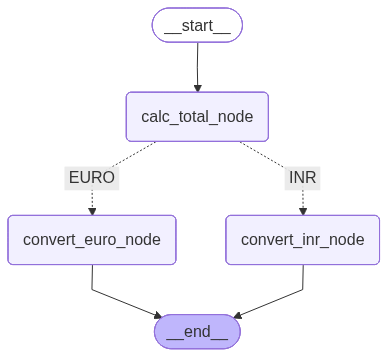

In [51]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"amount_usd": 100, "amount_cuurency": "INR"})

{'amount_usd': 100,
 'total_usd': 200.0,
 'amount_cuurency': 'INR',
 'total': 8200.0}

In [44]:
graph.invoke({"amount_usd": 4100, "amount_cuurency": "EURO"})

{'amount_usd': 4100,
 'total_usd': 8200.0,
 'amount_cuurency': 'EURO',
 'total': 3895.0}